In [23]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import datetime
today = datetime.date.today()
import pickle
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)
from flonacomldft.models.mixture import Mixture

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

In [24]:
T = 350
kBT_in_eV = kB * T
kBT_in_eV

0.030160656180260245

In [25]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Dataframe with all the args of the simulations

In [26]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [27]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args

### new MD simulations
isomers = [0]*9 + [1]*9
flows_ids = ['3077978'+str(i) for i in range(0, 18)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:s}.json'.format(number_id)
    f = open(subsubproject_path+'results_flow_is{:d}_{:s}/'.format(isomer_id,number_id)+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training-2212'] = df_args

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)


#### 0.0.1 - copying the files

In [28]:

# Load the data
PROJECT_PATH = '/mnt/home/amolina/ceph/adaptive-flow-mc'
SIMULATIONS_DATA_PATH = PROJECT_PATH+"/2-adaptive-mlp"
is_idx = {0: [32606140], 
        1: [32606143]
        }   

is_idx[0], is_idx[1]
adaptive_mlp = {}
cvs_mlp = {}

for i in range(2):
    adaptive_mlp[i] = []

    cvs_mlp[i] = []

    for j in is_idx[i]:
        print("rsync -av rusty:"+SIMULATIONS_DATA_PATH + "/results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl .".format(
                i, j, i, j))
        print("rsync -av rusty:"+SIMULATIONS_DATA_PATH + "/results_adaptive_is{:d}_{:d}/cvs_is{:d}_{:d}.pkl .".format(
                i, j, i, j))
        print("rsync -av rusty:"+SIMULATIONS_DATA_PATH + "/results_adaptive_is{:d}_{:d}/args_adaptive_sampling_{:d}.json .".format(
                i, j, j))

rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_32606140/adaptive_sampling_is0_32606140.pkl .
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_32606140/cvs_is0_32606140.pkl .
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_32606140/args_adaptive_sampling_32606140.json .
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is1_32606143/adaptive_sampling_is1_32606143.pkl .
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is1_32606143/cvs_is1_32606143.pkl .
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is1_32606143/args_adaptive_sampling_32606143.json .


In [18]:
# ##### ab-flowMC w.o. NP
# isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
# number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

# subsubproject_path = subproject_path + '/1-adaptive/'

# df_args = pd.DataFrame()
# for isomer_id, number_id in zip(isomers, number_ids):
#     args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
#     f = open(subsubproject_path+args_file)
#     data = json.load(f)
#     sub_df = pd.DataFrame(data)
#     df_args = df_args.append(sub_df)

# dic_args['ab-flowMC-wo-NP'] = df_args

##### ab-flowMC 
isomers = [0] + [1]
number_ids = [32606140, 32606143] 

subsubproject_path = subproject_path + '/2-adaptive-mlp/'
# project_path = project_path_ + '/2-adaptive-mlp/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/1365523118.py:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_2731/1365523118.py:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)


In [21]:
dic_args['ab-flowMC'].keys()
dic_args['ab-flowMC'][['process_id', 'isomer_label','N_md_points', 'N_random_points', 'n_steps',  'flow_n_iter', 'n_chains', 'frac_computed', 'n_runs', 'cycles']] 
# dic_args['ab-flowMC'][['process_id', 'isomer_label', 'N_random_points', 'flow_batch_size']]
# dic_args['ab-flowMC']


,process_id,isomer_label,N_md_points,N_random_points,n_steps,flow_n_iter,n_chains,frac_computed,n_runs,cycles
0,32606140,0,500,500,20,400,50,1.0,50,5
0,32606143,1,500,500,20,400,50,1.0,50,5


### 0.2 - Loading models

In [12]:
def load_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    if '3-flows-md' in project_path:
        f = 'is{:d}_flow_dic_{:d}.pkl'.format(isomer_id, process_id)
        if '3077' in str(process_id):
            f = 'results_flow_is{:d}_{:d}/'.format(isomer_id, process_id) + f
        models = [load_pickle_file(f, path=project_path)['model']]
    else:
        f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        dic_trainings = load_pickle_file(f, path=project_path)
        models = [ dic[0]['model'] for dic in dic_trainings['dict_flows'] ]
    return models

In [14]:
models = load_models(0, 32606140, project_path=subproject_path+ '/2-adaptive-mlp/')
len(models)

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


51

In [15]:
def load_mlp_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps']]
    
    return mlp_models

### 0.2.0 Selecting the best slices for the MLPs

Number of saved mlps: 10
Best model slice: 8
Number of saved mlps: 10
Best model slice: 9


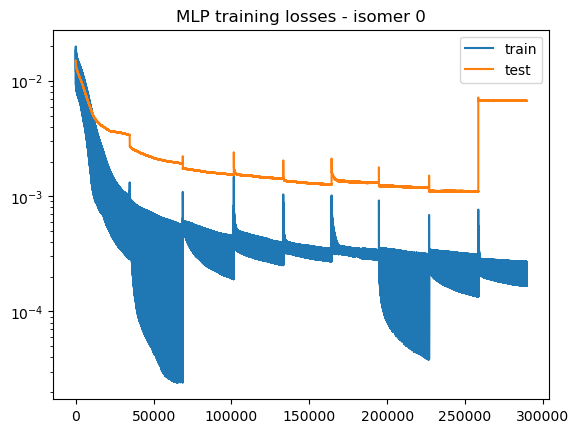

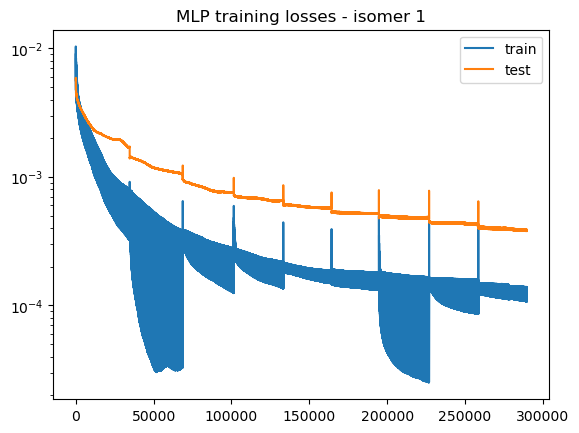

In [22]:
process_id_mlps = [32606140, 32606143]

for isomer_id in mode_labels:
    process_id_mlp = process_id_mlps[isomer_id]

    f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id_mlp)
    dic_trainings = load_pickle_file(f, path=subproject_path + '/2-adaptive-mlp/')
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps']]

    print('Number of saved mlps:', len(mlp_models))


    test_losses = []
    train_losses = []
    ## scan and keep the index of the best model
    test_loss_min = 100
    for train_slice in range(len(dic_trainings['dict_mlps'])):
        if train_slice == 0:
            continue
        test_losses += dic_trainings['dict_mlps'][train_slice][0]['test_losses']
        train_losses += dic_trainings['dict_mlps'][train_slice][0]['train_losses']

        if np.min(dic_trainings['dict_mlps'][train_slice][0]['test_losses']) < test_loss_min:
            test_loss_min = np.min(dic_trainings['dict_mlps'][train_slice][0]['test_losses'])
            best_model_slice = train_slice

    print('Best model slice:', best_model_slice)

    plt.figure()
    plt.title('MLP training losses - isomer {:d}'.format(isomer_id))
    plt.plot(train_losses, label='train')
    plt.plot(test_losses, label='test')
    plt.yscale('log')
    plt.legend()



OVERALL PARAMETERS:

In [39]:
process_id_mlps = [32606140, 32606143] ## adaptive with 500 initial MD samples + 500 random samples - ISO 0 and ISO 1
md_training_size = 500
random_point_mlp_training_sizes = [500]
flow_training_slices = np.linspace(0, 50, 11).astype(int)
flow_batch_size = 2000
mlp_train_slices = {0: 8, 1: 9}


#### 0.2.1 Test likelihoods - test data with corresponding MCMC

In [56]:
dic_results_test_abmc_flows = {
    'kind': [],
    'trial': [],
    'isomer_id': [],
    'md_training_size': [],
    'random_points_mlp_training': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'test_losses': [],
    # 'train_losses': [],
    'sample_size': [],
}

seed = 0
torch.manual_seed(seed)
# process_id_mlps = [30019623, 30019627] ## adaptive with 4000 initial MD samples ISO 0 and ISO 1

burnin = 1000
thin = 10


for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
    mlp_train_slice = mlp_train_slices[isomer_id]

    dic_mcmcs_abmc_flows = load_pickle_file('2024-03-15Ab-flows-MCMC-outputs.pkl', path=subproject_path + '9-mcmc-bar/')

    mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[mlp_train_slices[isomer_id]]

    for random_point_mlp_training_size in random_point_mlp_training_sizes:
        df_args = dic_args['ab-flowMC']
        df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N_random_points'] == random_point_mlp_training_size) & (df_args['flow_batch_size'] == flow_batch_size)]
        process_id_flow = df_isomer['process_id'][0]
        print('Isomer {:d} - MD training size {:d} - process id {:d}'.format(isomer_id, md_training_size, process_id_flow))
        flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/2-adaptive-mlp/')

        f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id_flow)
        dic_trainings = load_pickle_file(f, path=subproject_path + '/2-adaptive-mlp/')
        # train_losses = [ dic[0]['losses'] for dic in dic_trainings['dict_flows'] ]

        for flow_train_slice in flow_training_slices:
            # key = 'isomer_{:d}_md_training_size_{:d}_flow_train_slice_{:d}'.format(isomer_id, md_training_size, flow_train_slice)
            key = 'isomer_{:d}_md_training_size_{:d}_random_points_mlp_training_{:d}_flow_train_slice_{:d}'.format(isomer_id, md_training_size, random_point_mlp_training_size, flow_train_slice)
            mcmc_dic = dic_mcmcs_abmc_flows[key]
            mc_samples = mcmc_dic['xs'][burnin:][::thin]

            #shuffling
            # mc_samples = mcmc_dic['xs'][::10].reshape(-1, mcmc_dic['xs'].shape[-1])
            # mc_samples = mc_samples[torch.randperm(mc_samples.shape[0])].view(mcmc_dic['xs'].shape[0], -1, mcmc_dic['xs'].shape[-1])

            
            flow_model = flow_models[flow_train_slice]

            n_trial = 10
            n_chains = mc_samples.shape[1]
            n_chain_per_trial = n_chains // n_trial
            print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
            # print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
            # log_ratio_0_BARs = []
            # log_err_0_BARs = []

            for trial in range(n_trial):
                mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
                # print(mc_samples_t.shape)
                test_loss = flow_model.nll(mc_samples_t).mean().item()

                dic_results_test_abmc_flows['kind'].append('ab-flowMC')
                dic_results_test_abmc_flows['isomer_id'].append(isomer_id)
                dic_results_test_abmc_flows['md_training_size'].append(md_training_size)
                dic_results_test_abmc_flows['random_points_mlp_training'].append(random_point_mlp_training_size)
                dic_results_test_abmc_flows['process_id_flow'].append(process_id_flow)
                dic_results_test_abmc_flows['flow_train_slice'].append(flow_train_slice)
                dic_results_test_abmc_flows['mc seed'].append(seed)
                dic_results_test_abmc_flows['test_losses'].append(test_loss)
                dic_results_test_abmc_flows['trial'].append(trial)
                dic_results_test_abmc_flows['sample_size'].append(mc_samples_t.shape[0])
                dic_results_test_abmc_flows['mlp_train_slice'].append(mlp_train_slice)

Isomer 0 - MD training size 500 - process id 32606140
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Isomer 1 - MD training size 500 - process id 32606143
Total number of chains per trial = 20 and samples per trial = 18000
Total number of chains per trial = 20 and samples per trial = 18000
Total nu

In [20]:
# print(mc_samples.shape)
# mc_samples_t.shape[0]

In [57]:
# save results
date = str(today)
df = pd.DataFrame(dic_results_test_abmc_flows)
filename = subproject_path + '9-mcmc-bar/'+ date + '-test-losses-abmc-flows.csv'
df.to_csv(filename, index=False)
print(filename)


/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/20231911_adaptive_single_isomer/9-mcmc-bar/2024-03-15-test-losses-abmc-flows.csv


In [58]:
df

,kind,trial,isomer_id,md_training_size,random_points_mlp_training,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,test_losses,sample_size
0,ab-flowMC,0,0,500,500,32606140,0,8,0,-6.904962,18000
1,ab-flowMC,1,0,500,500,32606140,0,8,0,-7.086953,18000
2,ab-flowMC,2,0,500,500,32606140,0,8,0,-7.098117,18000
3,ab-flowMC,3,0,500,500,32606140,0,8,0,-6.700517,18000
4,ab-flowMC,4,0,500,500,32606140,0,8,0,-7.510140,18000
...,...,...,...,...,...,...,...,...,...,...,...
215,ab-flowMC,5,1,500,500,32606143,50,9,0,-11.251014,18000
216,ab-flowMC,6,1,500,500,32606143,50,9,0,-11.327919,18000
217,ab-flowMC,7,1,500,500,32606143,50,9,0,-11.165885,18000
218,ab-flowMC,8,1,500,500,32606143,50,9,0,-10.884797,18000


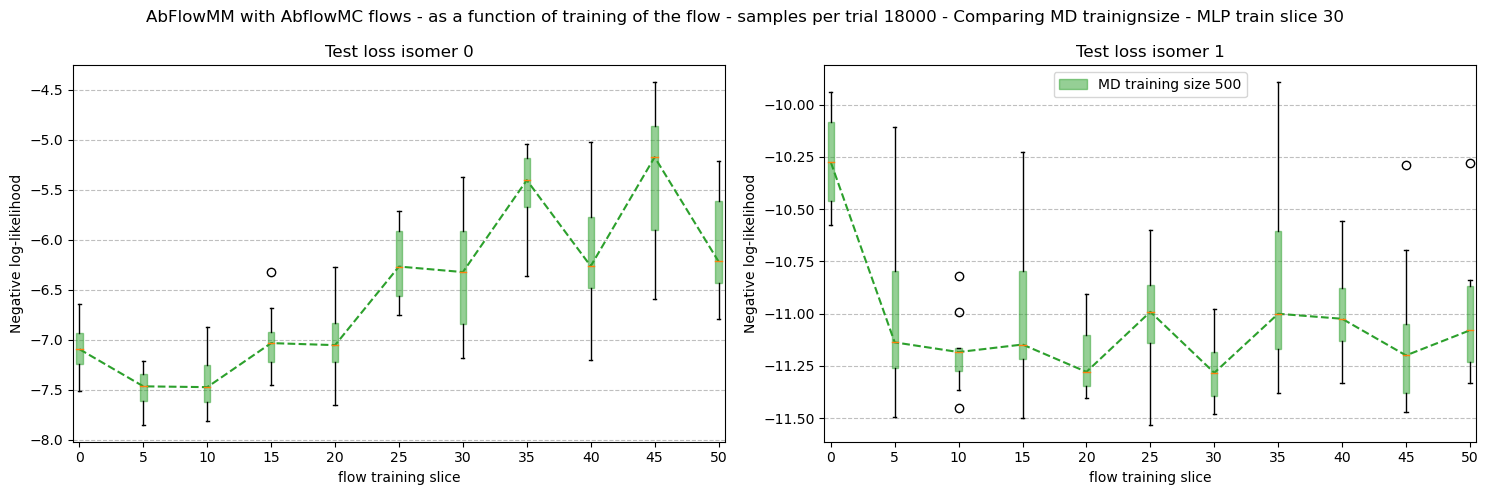

In [61]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2024-03-15-test-losses-abmc-flows'
df = pd.read_csv(filename + '.csv') 


sample_size = 18000

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    test_loss_0s = []
    test_loss_1s = []
    labels = []
    
    for flow_train_slice in flow_training_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['random_points_mlp_training'] == random_point_mlp_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        test_loss_0 = df_abflow_0['test_losses'].values
        test_loss_1 = df_abflow_1['test_losses'].values

        test_loss_0s.append(test_loss_0)
        test_loss_1s.append(test_loss_1)

        
    plt.sca(axs[0])
    plt.title(r'Test loss isomer 0'.format(sample_size))
    plt.boxplot(test_loss_0s,
                positions=flow_training_slices,
                # labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    # plot median
    plt.plot(flow_training_slices, np.median(test_loss_0s, axis=1), color='C{:d}'.format(m+2), linestyle='--')
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'Negative log-likelihood')
    
    plt.sca(axs[1])
    plt.title(r'Test loss isomer 1'.format(sample_size))
    plt.boxplot(test_loss_1s,
                positions=flow_training_slices,
                # labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    # plot median
    plt.plot(flow_training_slices, np.median(test_loss_1s, axis=1), color='C{:d}'.format(m+2), linestyle='--')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.xlabel('flow training slice')
    axs[1].set_ylabel(r'Negative log-likelihood')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_1 / Z_0 ')
    # plt.boxplot(zrs, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
    #             )
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

## METROPOLIS-HASTINGD

In [25]:
"""
Script with Metropolis-Hasting algorithm. 

"""

import time
import numpy as np
import torch
import tqdm

from flonacomldft.collective_variables import get_collective_variables
# from ase.parallel import parprint as print
from ase.units import kB


def run_metropolis(model, 
                    init, 
                    n_chains,
                    n_steps,
                    energy_type,
                    temperature,
                    mixture,
                    mlp_models=None,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=True,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=False,
                    device='cpu',
                    folder_name=None,
                 ):

    assert init.shape[0] == n_chains

    if mixture:
        try:
            assert len(model.models) > 1
        except:
            raise RuntimeError("Model is not a mixture")
    
    print("Running Metropolis-Hastings")

    x_init = init[:, :dim]
    u_init = init[:, dim]
    isomer_init = init[:, dim+1]

    beta = 1 / (kB * temperature)

    print("Number of chains: {:d}".format(n_chains))
    print("Number of steps: {:d}".format(n_steps))
    print("Temperature: {:.1f}K".format(temperature))
    print("Energy Type: {:s}".format(energy_type))

    if "mlp" in energy_type:
        #TODO: Add calculator for MLP
        
        if (mlp_models is None):
            raise RuntimeError("No model to calculate energy")
        
        if mixture:
            print('Mixture model')
            model_mlp_is0, model_mlp_is1 = mlp_models
        else:
            if(isomer_init.sum()==0):
                model_mlp_is0 = mlp_models[0]
            else:
                model_mlp_is1 = mlp_models[0]
        
        print("Use Neural Predictor: True")
    
    else:
        
        print("No Neural Predictor")

    use_calc = False

    if return_ratios:
        ratios = []

    if return_proposals:
        xs_proposals = []
        us_proposals = []
        isomers_proposals = []
        nlls_proposals = []

    print("Mixture Model: {:s}".format(str(mixture)))

    if mixture:
        weights = [model.weights.clone().detach()]

    xs = []
    us = []
    accs = []
    isomers = []
    nlls = []

    time_step_mcmc = []

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
        print("Step \t Acc Rate")

    for dt in pbar:

        if mixture:
            x_new, isomer_new = model.sample(n_chains, return_mus=True)
        else:
            x_new = model.sample(n_chains)
            isomer_new = isomer_init.clone()

        x_new = x_new.clone().detach() #set float
        isomer_new = isomer_new.clone().detach() #set dype
        
        nll_x = model.nll(x_new)
        nll_x_init = model.nll(x_init)

        if return_proposals:
            xs_proposals.append(x_new.clone().detach())
            isomers_proposals.append(isomer_new.clone().detach())
            nlls_proposals.append(nll_x.clone().detach())

        if "mlp" in energy_type:

            u_new = torch.zeros((n_chains, 1)).squeeze()

            if mixture:
                u_new[~isomer_new.bool()] = model_mlp_is0(x_new[~isomer_new.bool()]).reshape(1, -1)
                u_new[isomer_new.bool()] = model_mlp_is1(x_new[isomer_new.bool()]).reshape(1, -1)

            else:
                if(isomer_new.sum()==0):
                    u_new = model_mlp_is0(x_new)
                else:
                    u_new = model_mlp_is1(x_new)

            u_new = u_new.squeeze()

        time_step_mcmc.append(time.time())

        if return_proposals:
            us_proposals.append(u_new.clone().detach())
        
        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)

        if return_ratios:
            ratios.append( torch.min(ratio.clone().detach(), 
                            torch.ones_like(ratio)) )

        s = torch.rand_like(ratio)
        acc = s < torch.min(ratio.detach(), torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        if mixture:
            isomer_new[~acc] = isomer_init[~acc]
        
        else:
            isomer_new = isomer_init.clone()
        
        xs.append(x_new.clone().detach())
        us.append(u_new.clone().detach())
        accs.append(acc.clone().detach())
        isomers.append(isomer_new.clone().detach())
        nlls.append(model.nll(x_new).clone().detach())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description("Step {:d} \t Acceptance Rate {:.3f}".format(
                dt, acc.float().mean().item()))
        else:
            print("{:d} \t {:.3f}".format( dt, 
                                        acc.float().mean().item()
                                        )
            )

        if mixture and update_weights and dt > 0 and dt % scheduler_weights == 0:

            window_weights = torch.stack( [(~torch.stack(isomers).bool())[-scheduler_weights:].float().mean(),
                              torch.stack(isomers)[-scheduler_weights:].float().mean()] )

            new_weights = alpha * model.weights.clone() + (1 - alpha) * window_weights.clone()

            if torch.all(new_weights < 0.75):

                model.weights = new_weights.clone()

            weights.append(model.weights.clone().detach())

    to_return = {
        'xs': torch.stack(xs),
        'us': torch.stack(us),
        'accs': torch.stack(accs),
        'isomers': torch.stack(isomers),
        'nlls': torch.stack(nlls),
        'time_mcmc': time_step_mcmc,
    }

    if return_ratios:
        to_return['ratios'] = torch.stack(ratios)

    if return_proposals:
        to_return['xs_proposals'] = torch.stack(xs_proposals)
        to_return['us_proposals'] = torch.stack(us_proposals)
        to_return['isomers_proposals'] = torch.stack(isomers_proposals)
        to_return['nlls_proposals'] = torch.stack(nlls_proposals)

    if use_calc:
            
        to_return['xs_calc'] = torch.stack(xs_calc)
        to_return['us_calc'] = torch.stack(us_calc)
        to_return['isomers_calc'] = torch.stack(isomers_calc)
        to_return['inds_calc'] = torch.stack(inds_calc)

    if mixture and update_weights:
        to_return['weights'] = torch.stack(weights)

    return to_return


## 3.1 Runing and saving single isomers MCMC

### 3.1.2 Adaptive flows

In [36]:
print(process_id_mlps)
print('mlp train slice:', mlp_train_slices)
print('flow train slices:', flow_training_slices)

[32606140, 32606143]
mlp train slice: {0: 8, 1: 9}
flow train slices: [ 0  5 10 15 20 25 30 35 40 45 50]


In [41]:
dic_mcmcs_abmc_flows = {}


seed = 0
torch.manual_seed(seed)

# MH parameters
n_chains = 200
mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'
n_steps = 10000


for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
    mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[mlp_train_slices[isomer_id]]

    for random_point_mlp_training_size in random_point_mlp_training_sizes:
        df_args = dic_args['ab-flowMC']
        df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N_random_points'] == random_point_mlp_training_size) & (df_args['flow_batch_size'] == flow_batch_size)]
        process_id_flow = df_isomer['process_id'][0]
        flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/2-adaptive-mlp/')

        for flow_train_slice in flow_training_slices:
            flow_model = flow_models[flow_train_slice]
            init = flow_model.sample(n_chains)
            init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
        

            to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                                temperature,
                                mixture,
                                mlp_models=[mlp_model],
                                frac_computed=0.2,
                                dim=12,
                                update_weights=update_weights,
                                scheduler_weights=10,
                                alpha=0.5,
                                return_ratios=True,
                                return_proposals=True,
                                with_tqdm=True,
                                device='cpu',
                                folder_name=None,
                            )
            key = 'isomer_{:d}_md_training_size_{:d}_random_points_mlp_training_{:d}_flow_train_slice_{:d}'.format(isomer_id, md_training_size, random_point_mlp_training_size, flow_train_slice)
            dic_mcmcs_abmc_flows[key] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.090: 100%|██████████| 10000/10000 [01:11<00:00, 140.18it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.195: 100%|██████████| 10000/10000 [01:12<00:00, 137.41it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


...

Step 9999 	 Acceptance Rate 0.355: 100%|██████████| 10000/10000 [01:02<00:00, 160.48it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.390: 100%|██████████| 10000/10000 [01:02<00:00, 160.05it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.395: 100%|██████████| 10000/10000 [01:02<00:00, 159.32it/s]


In [42]:
list(dic_mcmcs_abmc_flows.keys())

['isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_0',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_5',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_10',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_15',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_20',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_25',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_30',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_35',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_40',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_45',
 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_50',
 'isomer_1_md_training_size_500_random_points_mlp_training_500_flow

In [44]:
# save the results
# date = '2023-12-05' # str(today)
date = str(today)
filename = subproject_path + '9-mcmc-bar/'+ date + '-Ab-flows-MCMC-outputs.pkl'
with open(filename, 'wb') as f:
    pickle.dump(dic_mcmcs_abmc_flows, f)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/20231911_adaptive_single_isomer/9-mcmc-bar/2024-03-15Ab-flows-MCMC-outputs.pkl


## 3.2 - Computing Deep BAR

<!-- ### 3.2.0 - MD flows are pure MD trajectories -->

### 3.2.2 - Adaptive flows

In [62]:
dic_mcmcs_abmc_flows.keys()

dict_keys(['isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_0', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_5', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_10', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_15', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_20', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_25', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_30', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_35', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_40', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_45', 'isomer_0_md_training_size_500_random_points_mlp_training_500_flow_train_slice_50', 'isomer_1_md_training_size_500_random_points_mlp_training_500_flow_

In [46]:
dic_args.keys()

dict_keys(['ab-flowMC'])

In [64]:
dic_results_bar_abmc_flows = {
    'kind': [],
    'isomer_id': [],
    'md_training_size': [],
    'random_point_mlp_training_size': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'log_r': [],
    'trial': [],
    'sample_size': [],
}

seed = 0
torch.manual_seed(seed)
# process_id_mlps = [30019623, 30019627] ## adaptive with 4000 initial MD samples ISO 0 and ISO 1
# process_id_mlps = [31959916, 31959919] ## adaptive with 500 initial MD samples + 500 random samples - ISO 0 and ISO 1
# md_training_size = 500 #[4000]
# random_point_mlp_training_sizes =  [500, 1500]
# training_slices = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
# mlp_train_slices = [30] #[0]

# dic_mcmcs_md_flows = load_pickle_file(subproject_path + '9-mcmc-bar/2023-12-05MD-flows-MCMC-outputs.pkl')

for mlp_train_slice in mlp_train_slices:

    dic_mcmcs_abmc_flows = load_pickle_file('2024-03-15Ab-flows-MCMC-outputs.pkl', path=subproject_path + '9-mcmc-bar/')

    for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):

        mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[mlp_train_slices[isomer_id]]

        for random_point_mlp_training_size in random_point_mlp_training_sizes:
            df_args = dic_args['ab-flowMC']
            # df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size) & (df_args['flow_batch_size'] == 1000)]
            df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N_random_points'] == random_point_mlp_training_size) & (df_args['flow_batch_size'] == flow_batch_size)]
            process_id_flow = df_isomer['process_id'][0]
            print('Isomer {:d} - MD training size {:d} - process id {:d}'.format(isomer_id, md_training_size, process_id_flow))
            flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/2-adaptive-mlp/')

            for flow_train_slice in flow_training_slices:
                # key = 'isomer_{:d}_md_training_size_{:d}_flow_train_slice_{:d}'.format(isomer_id, md_training_size, flow_train_slice)
                key = 'isomer_{:d}_md_training_size_{:d}_random_points_mlp_training_{:d}_flow_train_slice_{:d}'.format(isomer_id, md_training_size, random_point_mlp_training_size, flow_train_slice)
                mcmc_dic = dic_mcmcs_abmc_flows[key]
                mc_samples = mcmc_dic['xs']
                
                flow_model = flow_models[flow_train_slice]

                prop = flow_model
                target_u = mlp_model

                n_trial = 10
                n_chains = mc_samples.shape[1]
                n_chain_per_trial = n_chains // n_trial
                print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
                log_ratio_0_BARs = []
                log_err_0_BARs = []

                for trial in range(n_trial):
                    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
                    prop_samples_t = prop.sample(mc_samples_t.shape[0])
                    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
                    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
                    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
                    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


                    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                    log_ratio_0_BARs.append(logr)
                    log_err_0_BARs.append(logr_err)

                    dic_results_bar_abmc_flows['kind'].append('ab-flowMC')
                    dic_results_bar_abmc_flows['isomer_id'].append(isomer_id)
                    dic_results_bar_abmc_flows['md_training_size'].append(md_training_size)
                    dic_results_bar_abmc_flows['random_point_mlp_training_size'].append(random_point_mlp_training_size)
                    dic_results_bar_abmc_flows['process_id_flow'].append(process_id_flow)
                    dic_results_bar_abmc_flows['flow_train_slice'].append(flow_train_slice)
                    dic_results_bar_abmc_flows['mc seed'].append(seed)
                    dic_results_bar_abmc_flows['log_r'].append(logr)
                    dic_results_bar_abmc_flows['trial'].append(trial)
                    dic_results_bar_abmc_flows['sample_size'].append(mc_samples_t.shape[0])
                    dic_results_bar_abmc_flows['mlp_train_slice'].append(mlp_train_slice)

Isomer 0 - MD training size 500 - process id 32606140
Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.794214651657967e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 6.7700673582749005e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.784953323953232e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.3809743626989075e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.4760595610805467e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.6867003012066561e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.855989379213497e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.7428708051502326e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.789725323917082e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.790333442386327e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/an

Total number of chains per trial = 20 and samples per trial = 200000


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.012404680977852e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.6720703683859028e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.6818967196741141e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.8668100355844217e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.727843330305404e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 9.538508720652317e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.762401886182488e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.9979963755977224e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.775041787752343e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.7854524944359582e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/an

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 8.12532391591958e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.03111792479649e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.0065538731396373e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -7.058100948142965e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.538603933378909e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/ana

In [65]:
df = pd.DataFrame(dic_results_bar_abmc_flows)
df

,kind,isomer_id,md_training_size,random_point_mlp_training_size,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,log_r,trial,sample_size
0,ab-flowMC,0,500,500,32606140,0,0,0,-212.883806,0,200000
1,ab-flowMC,0,500,500,32606140,0,0,0,-212.846011,1,200000
2,ab-flowMC,0,500,500,32606140,0,0,0,-212.782290,2,200000
3,ab-flowMC,0,500,500,32606140,0,0,0,-212.874896,3,200000
4,ab-flowMC,0,500,500,32606140,0,0,0,-212.778352,4,200000
...,...,...,...,...,...,...,...,...,...,...,...
435,ab-flowMC,1,500,500,32606143,50,1,0,-208.105219,5,200000
436,ab-flowMC,1,500,500,32606143,50,1,0,-208.093570,6,200000
437,ab-flowMC,1,500,500,32606143,50,1,0,-208.106413,7,200000
438,ab-flowMC,1,500,500,32606143,50,1,0,-208.132235,8,200000


In [220]:
# filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
# df_old = pd.read_csv(filename + '.csv') 

# df = pd.DataFrame(dic_results_bar_abmc_flows)

# df_combined = pd.concat([df_old, df])


In [66]:
df = pd.DataFrame(dic_results_bar_abmc_flows)
filename = subproject_path + '9-mcmc-bar/'+ str(today) + '-abmc-flows-BAR-results.csv'
print(filename)
df.to_csv(filename, index=False)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/20231911_adaptive_single_isomer/9-mcmc-bar/2024-03-15-abmc-flows-BAR-results.csv


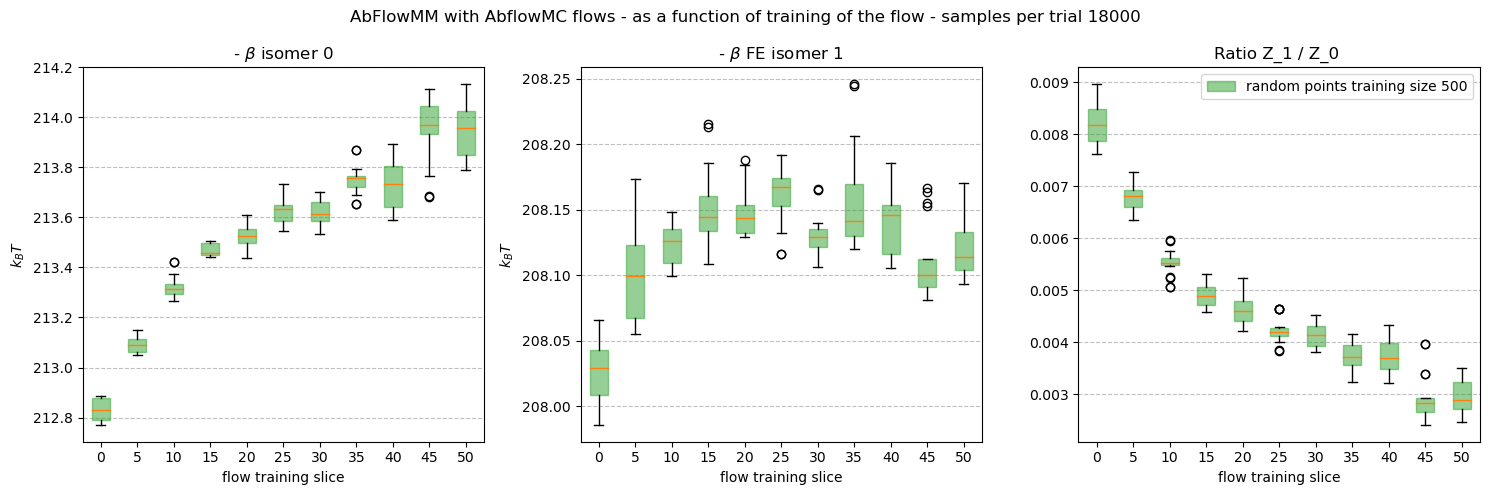

In [69]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches

# filename = subproject_path + '9-mcmc-bar/2024-02-26-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
filename = subproject_path + '9-mcmc-bar/'+ str(today) + '-abmc-flows-BAR-results.csv'
df = pd.read_csv(filename) 

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d}'.format(sample_size))
sample_size = 200000

handles = []
# AbFlowMM results - flow training slice -1
for m, random_point_mlp_training_size in enumerate(random_point_mlp_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_training_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['random_point_mlp_training_size'] == random_point_mlp_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'- $\beta$ isomer 0'.format(sample_size))
    plt.boxplot(z0s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
               
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'$k_B T$')
    
    plt.sca(axs[1])
    plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
    plt.boxplot(z1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[1].set_ylabel(r'$k_B T$')

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='random points training size {:d}'.format(md_training_size))
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()
plt.savefig(filename + '_randpttrainingsize_both.png'.format(md_training_size), dpi=300)

# 4 - Putting MCMC + BAR together

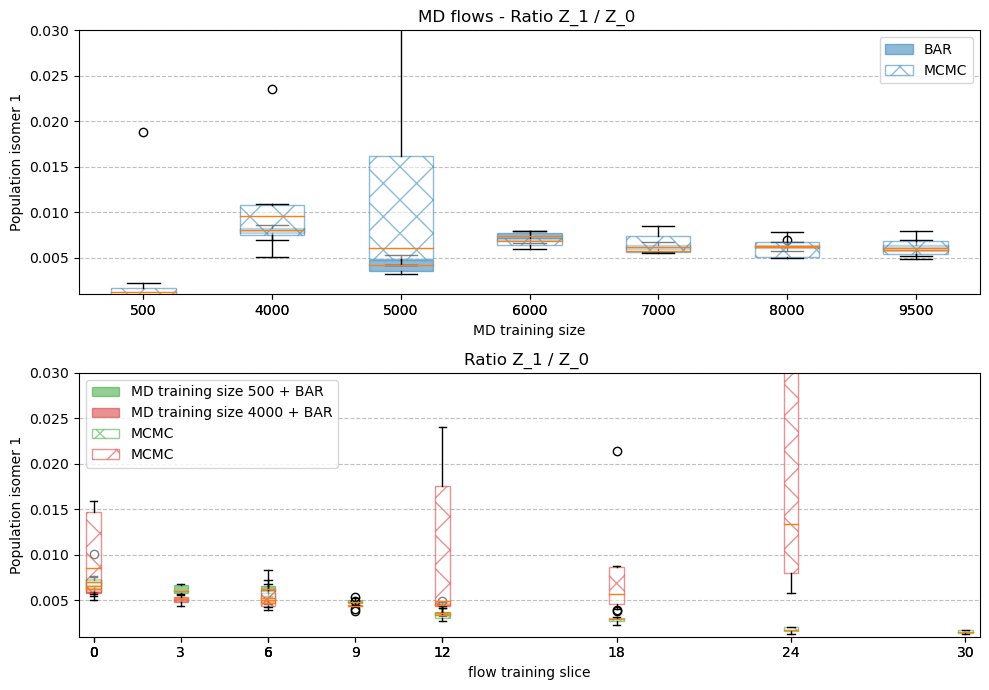

In [158]:
plt.figure(figsize=(10, 7))
axs = [plt.subplot(211),plt.subplot(212)]
# plt.suptitle('AbFlowMM with MD flows - samples per trial {:d} - - MLP train slice {:d}'.format(sample_size, mlp_train_slice))


### MD FLOWS BAR
handles = []
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

## first batch of MD training
# filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
# df = pd.read_csv(filename + '.csv')
# md_training_sizes = [500, 1000, 2000, 4000]


# second batch of MD training
filename = subproject_path + '9-mcmc-bar/2024-02-26-MD-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]

sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []


for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

plt.sca(axs[0])
plt.title('MD flows - Ratio Z_1 / Z_0 ')
plt.boxplot(zrs, labels=labels,patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

red_patch = mpatches.Patch(color = "C0".format(m+2), alpha=0.5, label='BAR')
handles.append(red_patch)


## MD Flows MCMCs

mlp_train_slice = 30

# # first batch of MD training
# filename = subproject_path + '9-mcmc-bar/2023-12-07-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
# df = pd.read_csv(filename + '.csv') 
# md_training_sizes = [500, 1000, 2000, 4000]

# second batch of MD training
filename = subproject_path + '9-mcmc-bar/2023-12-22-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]


flow_training_slices = [0] #, 12, 18, 24, 30]
mlp_train_slices = [30] #[0]
sample_size = 180000


for f,flow_train_slice in enumerate(flow_train_slices):
    pop_isomer_1s = []
    labels = []
    for md_training_size in md_training_sizes:
     
        labels.append('{:d}'.format(md_training_size))
        df_md = df.loc[df['kind'] == 'MD']
        df_md = df_md.loc[df_md['md_training_size'] == md_training_size]
        df_md = df_md.loc[df_md['flow_train_slice'] == flow_train_slice]
        df_md = df_md.loc[df_md['sample_size'] == sample_size]

        pop_isomer_1 = df_md['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
    
    plt.sca(axs[0])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "w", color = "C{:d}".format(f), hatch = 'x', alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", edgecolor = "C{:d}".format(f), hatch = 'x', alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('MD training size')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)


plt.legend(handles=handles)

##############################################################
#### ABMC FLOWS BAR

# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]


sample_size = 200000
flow_train_slices = [0, 3, 6, 9, 12] #, 15, 18, 21, 24, 27, 30]

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[1])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d} + BAR'.format(md_training_size))
    handles.append(red_patch)


###### ABMC FLOWS MCMC
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-abmc-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 180000	
flow_train_slices = [0, 6, 12, 18, 24, 30]

# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        

    plt.sca(axs[1])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "w", hatch='x', color = "C{:d}".format(m+2), alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", hatch='x', edgecolor = "C{:d}".format(m+2), alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)



plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

    

plt.legend(handles=handles)




plt.tight_layout()
# plt.savefig(filename + '.png', dpi=300)

# 5 - As a function of the number of DFT evaluations

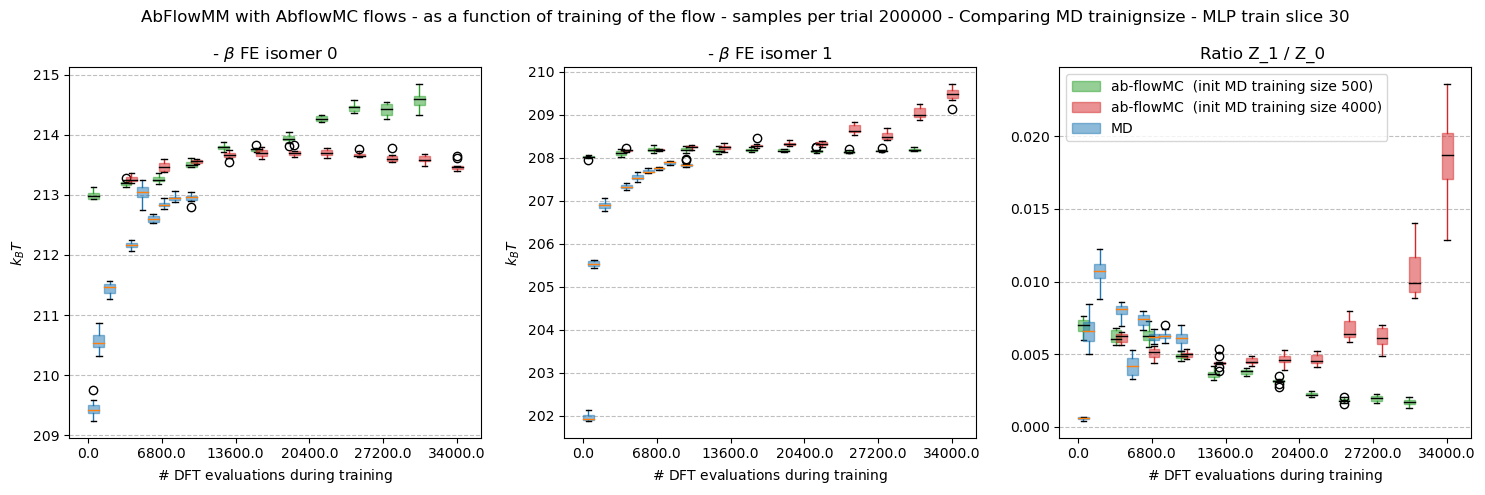

In [150]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'- $\beta$ isomer 0'.format(sample_size))
    plt.boxplot(z0s, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
               
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'$k_B T$')
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))
    
    plt.sca(axs[1])
    plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
    box_plot = plt.boxplot(z1s, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[1].set_ylabel(r'$k_B T$')
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='ab-flowMC  (init MD training size {:d})'.format(md_training_size))
    handles.append(red_patch)

    
    
########### ADDING MD results
mlp_train_slice = 30

# # first batch of MD
# filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
# df = pd.read_csv(filename + '.csv')
# md_training_sizes = [500, 1000, 2000, 4000]

# second batch of MD training
filename = subproject_path + '9-mcmc-bar/2023-12-22-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000, 5000, 6000, 7000, 8000, 9500]


sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []

for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        
plt.sca(axs[0])
plt.title(r'- $\beta$ FE isomer 0'.format(sample_size))
plt.boxplot(z0s, 
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[0].set_ylabel(r'$k_B T$')
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

plt.sca(axs[1])
plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
plt.boxplot(z1s, 
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[1].set_axisbelow(True)
axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[1].set_ylabel(r'$k_B T$')
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

plt.sca(axs[2])
plt.title('Ratio Z_1 / Z_0 ')
plt.boxplot(zrs,
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[2].set_axisbelow(True)
axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))
    

blue_patch = mpatches.Patch(color = "C0", alpha=0.5, label='MD')
handles.append(blue_patch)


plt.legend(handles=handles)
plt.tight_layout()
plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

## OLD BELOW

## 3.1 - doing it for each isomer separately and combining

### 3.1.1 - MD flows

In [55]:
flow_train_slice = -1

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

df_args = dic_args['MD-training']
df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
# df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]
print(process_id_flow)

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]


process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_0 = to_return_md_flow


KeyError: 'MD-training'

In [54]:
process_id_flow

0    30019623
0    30007103
Name: process_id, dtype: int64

In [190]:
mc_samples = to_return_md_flow_isomer_0['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.066221585688254e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -8.983137433915545e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.441279920300076e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.08154372419267e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.4429462282805616e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/ana

In [191]:
seed = 42
seed = 0
torch.manual_seed(seed)
flow_train_slice = -1

isomer_id = 1
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_1 = to_return_md_flow


In [192]:
mc_samples = to_return_md_flow_isomer_1['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    print(mc_samples_t.shape, prop_samples_t.shape)
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)
    
    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000
torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.813443072431255e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.052849535833957e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.913551206049306e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.4402961186260654e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.8000235374747717e-06 reached.
  warnings.warn(msg, RuntimeWarning)


array([0.00445801, 0.00361745, 0.00570963, 0.00576201, 0.00580109,
       0.00578588, 0.00539244, 0.00639434, 0.00618031, 0.00518968])

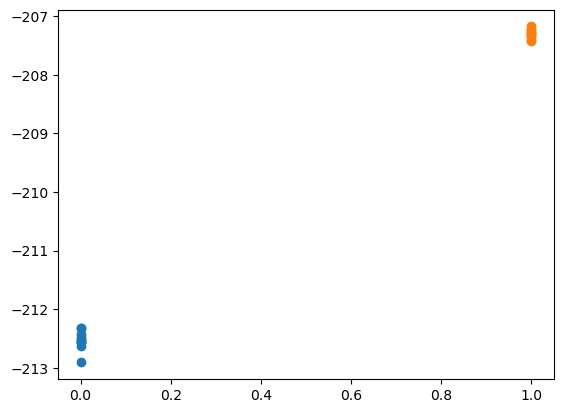

In [193]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

### 3.1.2 - AbFlowMC flows

In [249]:
# to_return_abflow_flow_isomer_0 = {}
# to_return_abflow_flow_isomer_1 = {}

In [250]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.190: 100%|██████████| 10000/10000 [01:19<00:00, 125.05it/s]


In [251]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.734594088200538e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.051756465310973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.276797770013218e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.2958616316136613e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0579815636901913e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

In [252]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.350: 100%|██████████| 10000/10000 [01:20<00:00, 124.04it/s]


In [253]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)



Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.20969910112035e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9140110794069187e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1856887454086973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 6.324223420506314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.463610364131455e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

array([0.00985862, 0.00497796, 0.00507602, 0.00940107, 0.00650915,
       0.00720697, 0.00513924, 0.01483733, 0.0080894 , 0.01203729])

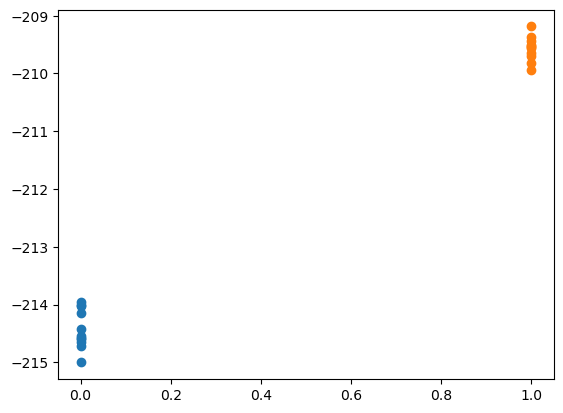

In [203]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

#### 3.1.2.2 Flow training slice 10

In [206]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.235: 100%|██████████| 10000/10000 [01:17<00:00, 129.18it/s]


In [207]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.5204953715274314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.9066644938448007e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 7.617337729470819e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.676465062582793e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 9.439617372208886e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

In [208]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.310: 100%|██████████| 10000/10000 [01:17<00:00, 129.31it/s]


In [209]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.641064727664343e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0589900227842008e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.6712616002223513e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0588534848920972e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.5829195610403985e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

array([0.00378317, 0.00406613, 0.00310225, 0.00337917, 0.00400396,
       0.00332852, 0.00350355, 0.00391103, 0.00382356, 0.00433757])

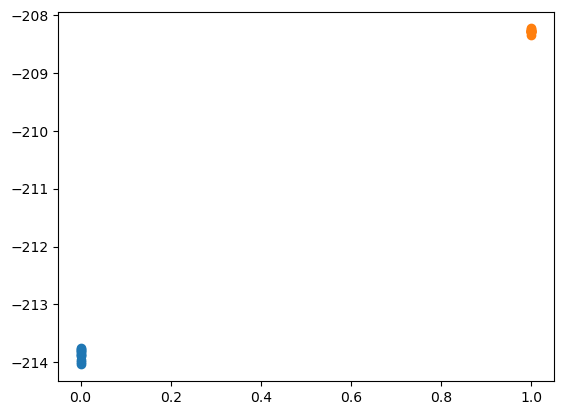

In [210]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

# SAVING THE DATA

In [31]:
import datetime
today = datetime.date.today()
import pickle

In [33]:
# dic_mcmcs = {
#     'md_0': to_return_md_flow_isomer_0,
#     'abflow_0': to_return_abflow_flow_isomer_0,
#     'md_1': to_return_md_flow_isomer_1,
#     'abflow_1': to_return_abflow_flow_isomer_1
# }
# with open(subproject_path + '/'+str(today)+'-MCMC-outputs.pkl', 'wb') as f:
#     pickle.dump(dic_mcmcs, f)

# load
with open(subproject_path + '/2023-12-01-MCMC-outputs.pkl', 'rb') as f:
    dic_mcmcs = pickle.load(f)

In [36]:
# df = pd.DataFrame(dic_results_all)
# df.to_csv(subproject_path + '/'+str(today)+'-BAR-results.csv', index=False)




{'whiskers': [<matplotlib.lines.Line2D at 0x29ef76c10>,
 'caps': [<matplotlib.lines.Line2D at 0x293a67090>,
 'boxes': [<matplotlib.lines.Line2D at 0x293a64490>,
 'medians': [<matplotlib.lines.Line2D at 0x2959242d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x29ee4cc90>,
 'means': []}

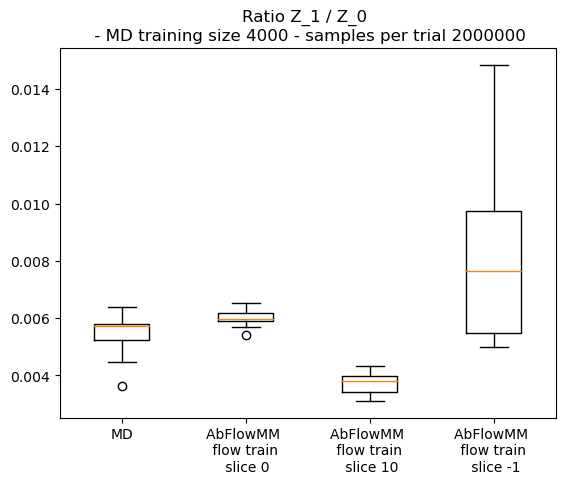

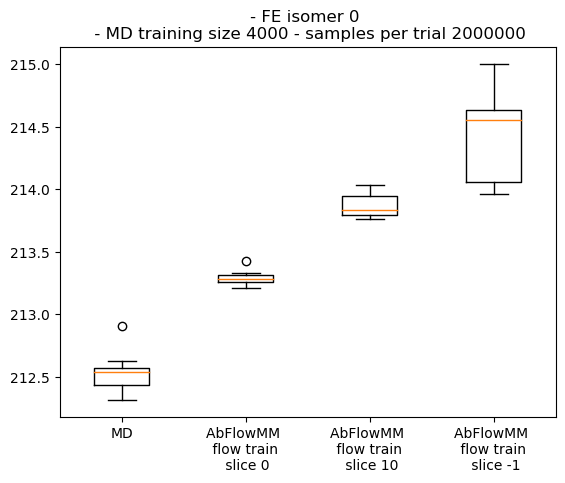

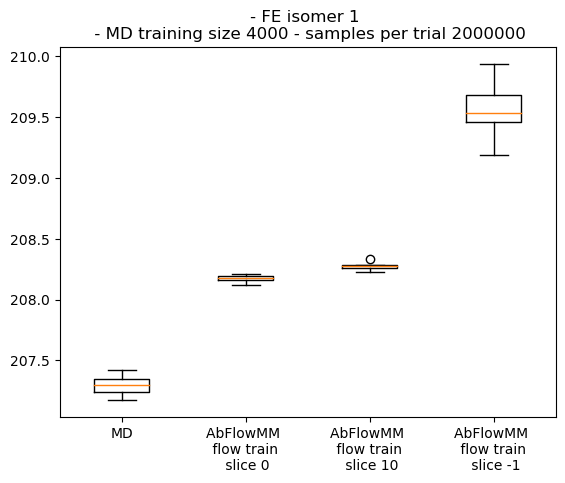

In [47]:
# plot boxplots of ratio of partition functions

df = pd.read_csv(subproject_path + '/2023-12-01-BAR-results.csv') 
n_chain_per_trial = 200
n_steps = 10000

zrs = []
z0s = []
z1s = []
labels = []

# MD results
labels.append('MD')
df_md = df.loc[df['kind'] == 'MD']
df_md_0 = df_md.loc[df_md['isomer_id'] == 0]
df_md_1 = df_md.loc[df_md['isomer_id'] == 1]

log_r_0 = df_md_0['log_r'].values
log_r_1 = df_md_1['log_r'].values

z_r_md = np.exp(log_r_0 - log_r_1)
zrs.append(z_r_md)

z_0_md = (-log_r_0)
z_1_md = (-log_r_1)
z0s.append(z_0_md)
z1s.append(z_1_md)

# AbFlowMM results - flow training slice -1
for train_slice in [0,10,-1]:
    labels.append('AbFlowMM \n flow train \n slice {:d}'.format(train_slice))
    df_abflow = df.loc[df['kind'] == 'AbFlowMM']
    df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0) & (df_abflow['flow_train_slice'] == train_slice)]
    df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1) & (df_abflow['flow_train_slice'] == train_slice)]

    log_r_0 = df_abflow_0['log_r'].values
    log_r_1 = df_abflow_1['log_r'].values

    z_r = np.exp(log_r_0 - log_r_1)
    zrs.append(z_r)

    z_0 = (-log_r_0)
    z_1 = (-log_r_1)
    z0s.append(z_0)
    z1s.append(z_1)



plt.figure()
plt.title('Ratio Z_1 / Z_0 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(zrs, labels=labels)

plt.figure()
plt.title('- FE isomer 0 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z0s, labels=labels)

plt.figure()
plt.title('- FE isomer 1 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z1s, labels=labels)
